# 🔍 Analyse Multi-Échelle du Dataset VoxConverse

Ce notebook analyse le dataset VoxConverse à différentes échelles temporelles pour comprendre la distribution des speakers et les patterns de silence.

## 🎯 Objectifs :
1. **Segmentation multi-échelle** - 5 sec, 1 min, 3 min
2. **Échantillons audio interactifs** - 4 échantillons par échelle avec contrôles audio
3. **Détection OSD** - Sélection d'échantillons avec overlaps
4. **Analyse statistique** - Distribution speakers + pourcentage silence

## 📊 Échelles analysées :
- **5 secondes** - Segments courts pour détection fine
- **1 minute** - Segments moyens pour patterns conversationnels  
- **3 minutes** - Segments longs pour analyse contextuelle

## 1. 🚀 Configuration de l'environnement

In [ ]:
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torchaudio
from datasets import load_dataset
from IPython.display import HTML, Audio, display
import pandas as pd
from tqdm import tqdm
import random
import warnings
import json
from datetime import datetime
import base64
import io
warnings.filterwarnings("ignore")

# Configuration des graphiques
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 8)

print("🚀 Configuration de l'environnement d'analyse...")
print(f"📍 Répertoire de travail: {os.getcwd()}")
print(f"🐍 Version Python: {sys.version.split()[0]}")
print(f"🔥 Version PyTorch: {torch.__version__}")

# Ajout du path pour les modules locaux
sys.path.append('/home/dev/Speaker-diarization-/src')

# Configuration des constantes
SAMPLE_RATE = 16000
N_MELS = 80
MAX_SPEAKERS = 8
FRAME_DURATION = 0.02  # 20ms

# Échelles d'analyse
TIME_SCALES = {
    '10sec': 10.0,
    '30sec': 30.0, 
    '3min': 180.0
}

SAMPLES_PER_SCALE = 3

print(f"✅ Configuration terminée!")
print(f"🎯 Échelles d'analyse: {list(TIME_SCALES.keys())}")
print(f"📊 Échantillons par échelle: {SAMPLES_PER_SCALE}")

🚀 Configuration de l'environnement d'analyse...
📍 Répertoire de travail: /home/dev/Speaker-diarization-
🐍 Version Python: 3.12.3
🔥 Version PyTorch: 2.8.0+cu129
✅ Configuration terminée!
🎯 Échelles d'analyse: ['5sec', '20sec', '1min']
📊 Échantillons par échelle: 2


## 2. 📥 Chargement du Dataset VoxConverse

In [2]:
def load_voxconverse_dataset():
    """Charge le dataset VoxConverse depuis Hugging Face avec extraction audio complète."""
    try:
        print("📥 Chargement du dataset VoxConverse avec VoxConverseDataset...")
        
        # Import et chargement via votre VoxConverseDataset
        sys.path.append('/home/dev/Speaker-diarization-/src')
        from voxconverse_dataset import VoxConverseDataset
        
        # Utilisation des paramètres corrects (sans max_duration)
        dataset_custom = VoxConverseDataset(split='dev', segment_duration=4.0)
        raw_dataset = dataset_custom.dataset  # Accès au dataset HuggingFace sous-jacent
        
        print(f"✅ Dataset chargé avec succès!")
        print(f"📊 Nombre de conversations brutes: {len(raw_dataset)}")
        print(f"📊 Nombre de segments préparés: {len(dataset_custom)}")
        
        # Test d'accès au premier échantillon
        if len(raw_dataset) > 0:
            sample = raw_dataset[0]
            print(f"\n🔍 Premier échantillon (conversation brute):")
            
            # Debug de l'AudioDecoder torchcodec
            audio_data = sample['audio']
            print(f"   Type audio_data: {type(audio_data)}")
            
            try:
                # Méthode correcte pour torchcodec AudioDecoder
                if hasattr(audio_data, 'get_all_samples'):
                    # Extraction complète de l'audio
                    audio_samples = audio_data.get_all_samples()
                    print(f"   ✅ Type AudioSamples: {type(audio_samples)}")
                    print(f"   ✅ AudioSamples attributes: {dir(audio_samples)}")
                    
                    # Tentative d'accès aux données audio
                    if hasattr(audio_samples, 'data'):
                        audio_tensor = audio_samples.data
                        print(f"   ✅ Audio tensor shape: {audio_tensor.shape}")
                        print(f"   ✅ Audio tensor dtype: {audio_tensor.dtype}")
                        
                        # Conversion en numpy
                        audio_numpy = audio_tensor.squeeze().numpy()
                        print(f"   ✅ Audio numpy shape: {audio_numpy.shape}")
                        print(f"   ✅ Audio min/max: {audio_numpy.min():.4f}/{audio_numpy.max():.4f}")
                        print(f"   ✅ Durée audio: {len(audio_numpy)/16000:.1f}s (supposant 16kHz)")
                        
                    elif hasattr(audio_samples, 'sample_rate'):
                        print(f"   Sample rate: {audio_samples.sample_rate}")
                        
                    else:
                        print(f"   AudioSamples contenu non accessible directement")
                        # Essayer d'itérer
                        try:
                            audio_list = list(audio_samples)
                            print(f"   AudioSamples comme liste: {len(audio_list)} éléments")
                            if len(audio_list) > 0:
                                print(f"   Premier élément type: {type(audio_list[0])}")
                        except:
                            pass
                    
                else:
                    print(f"   ❌ get_all_samples non disponible")
                    print(f"   Méthodes disponibles: {[m for m in dir(audio_data) if not m.startswith('_')]}")
                
            except Exception as e:
                print(f"   ❌ Erreur extraction audio torchcodec: {e}")
                import traceback
                traceback.print_exc()
            
            # Annotations
            print(f"\n📋 Annotations:")
            print(f"   Nombre d'annotations: {len(sample['timestamps_start'])}")
            print(f"   Speakers uniques: {len(set(sample['speakers']))}")
            if len(sample['timestamps_start']) > 0:
                print(f"   Premier timestamp: {sample['timestamps_start'][0]:.2f}s")
                print(f"   Dernier timestamp: {sample['timestamps_end'][-1]:.2f}s")
                print(f"   Premier speaker: {sample['speakers'][0]}")
                print(f"   Durée totale annotations: {sample['timestamps_end'][-1] - sample['timestamps_start'][0]:.1f}s")
        
        return dataset_custom, raw_dataset
        
    except Exception as e:
        print(f"❌ Erreur chargement dataset: {e}")
        import traceback
        traceback.print_exc()
        return None, None

# Chargement du dataset
voxconverse_dataset, voxconverse_dev = load_voxconverse_dataset()

📥 Chargement du dataset VoxConverse avec VoxConverseDataset...
Loading VoxConverse dev split...
  Processing conversation 1/216
  Processing conversation 1/216
  Processing conversation 51/216
  Processing conversation 51/216
  Processing conversation 101/216
  Processing conversation 101/216
  Processing conversation 151/216
  Processing conversation 151/216
  Processing conversation 201/216
  Processing conversation 201/216
✅ Prepared 34070 segments from 216 conversations
✅ Dataset chargé avec succès!
📊 Nombre de conversations brutes: 216
📊 Nombre de segments préparés: 34070

🔍 Premier échantillon (conversation brute):
   Type audio_data: <class 'datasets.features._torchcodec.AudioDecoder'>
   ✅ Type AudioSamples: <class 'torchcodec._frame.AudioSamples'>
   ✅ AudioSamples attributes: ['__abstractmethods__', '__annotations__', '__class__', '__class_getitem__', '__dataclass_fields__', '__dataclass_params__', '__delattr__', '__dict__', '__dir__', '__doc__', '__eq__', '__format__', '__ge

## 5. 🎵 Affichage des échantillons audio interactifs

🎵 ANALYSE DES DONNÉES PRÉ-CALCULÉES DU VOXCONVERSE DATASET
📊 Récupération d'échantillons depuis VoxConverseDataset...

🔍 Collecte pour échelle 5sec (5.0s)...
Loading VoxConverse dev split...
  Processing conversation 1/216
  Processing conversation 1/216
  Processing conversation 51/216
  Processing conversation 51/216
  Processing conversation 101/216
  Processing conversation 101/216
  Processing conversation 151/216
  Processing conversation 151/216
  Processing conversation 201/216
  Processing conversation 201/216
✅ Prepared 34102 segments from 216 conversations
   📊 Dataset chargé: 34102 segments disponibles
   ✅ 2 échantillons sélectionnés
     #1: Dataset idx 0, 1 speakers, overlap: ❌
     #2: Dataset idx 1, 1 speakers, overlap: ❌

🔍 Collecte pour échelle 20sec (20.0s)...
Loading VoxConverse dev split...
✅ Prepared 34102 segments from 216 conversations
   📊 Dataset chargé: 34102 segments disponibles
   ✅ 2 échantillons sélectionnés
     #1: Dataset idx 0, 1 speakers, overlap: ❌

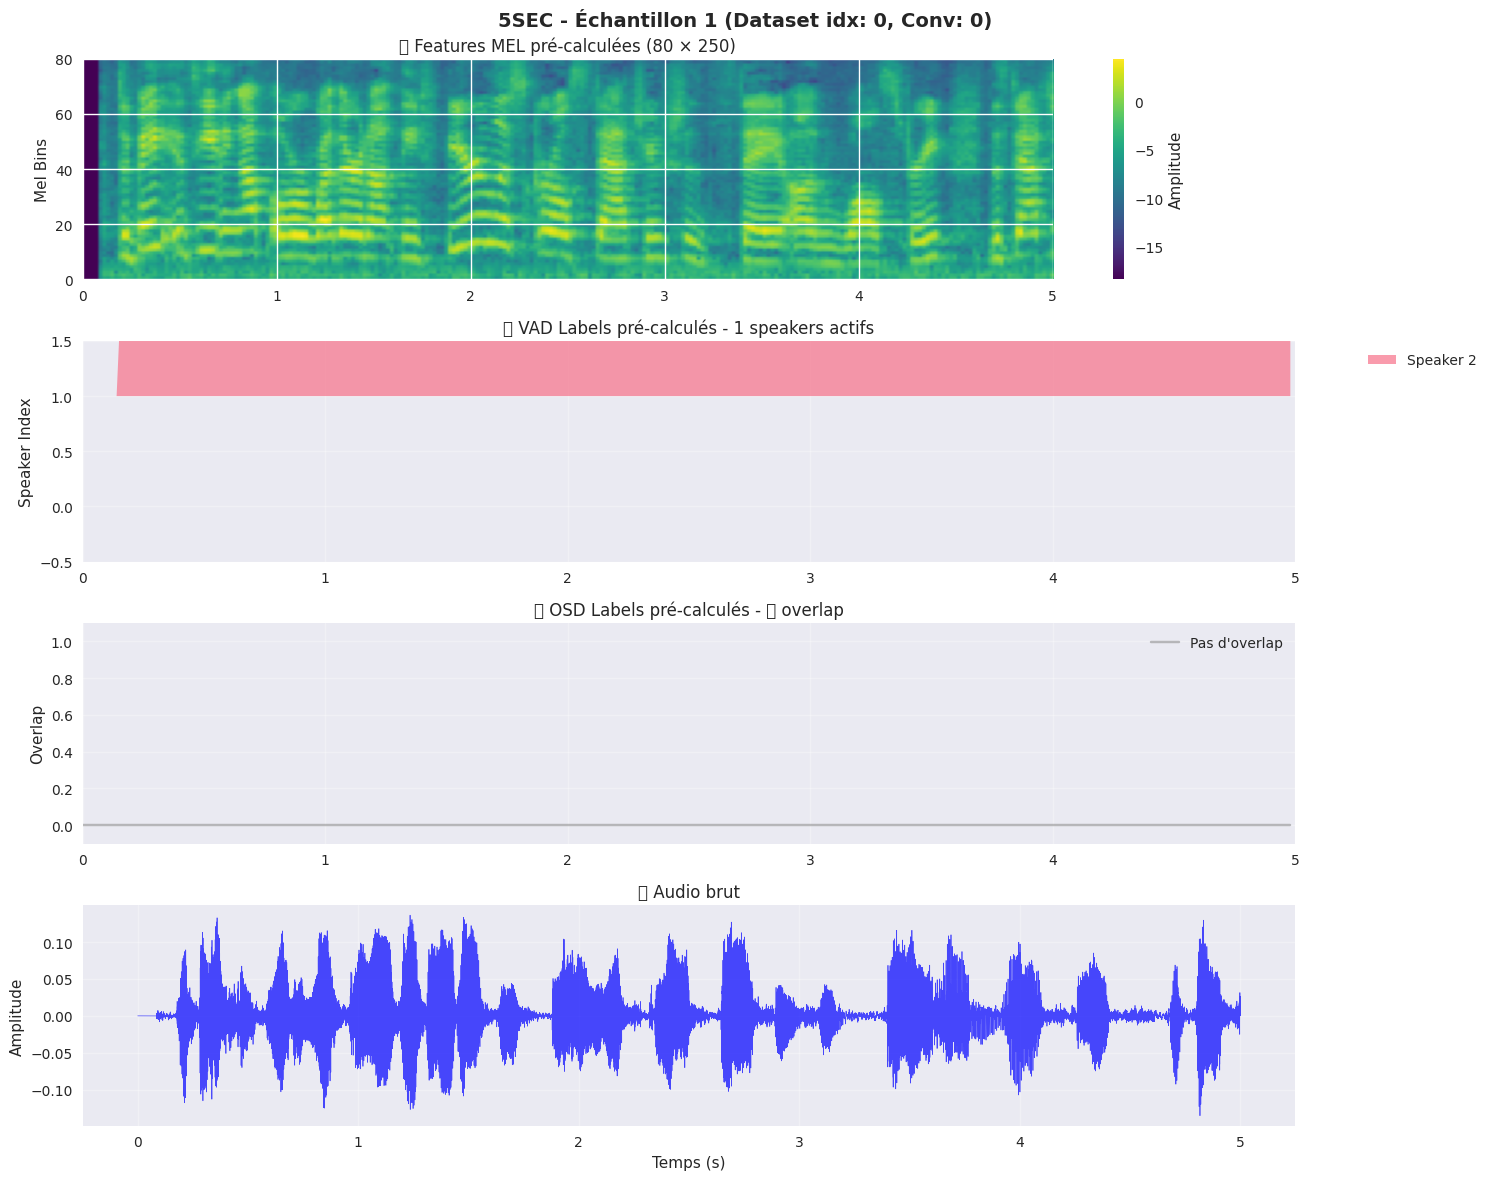

📊 Analyse des données pré-calculées:
   📁 Dataset index: 0 | Conversation: 0 | Start: 0.0s
   🎵 Audio brut: (80000,) samples (5.0s)
   🎼 Features MEL: (80, 250) (mel_bins × frames)
   🎤 VAD labels: (250, 8) (frames × max_speakers)
   🔄 OSD labels: (250,) frames
   📊 Valeurs MEL: [-18.42, 4.45]
   ️ Speakers actifs: 1 ([1])
   🔄 Frames avec overlap: 0/250 (0.0%)
   🤐 Frames avec activité vocale: 242/250 (96.8%)



⏱️ Temps traitement échantillon: 0.30s

📊 ÉCHANTILLON 2/2 - 5SEC


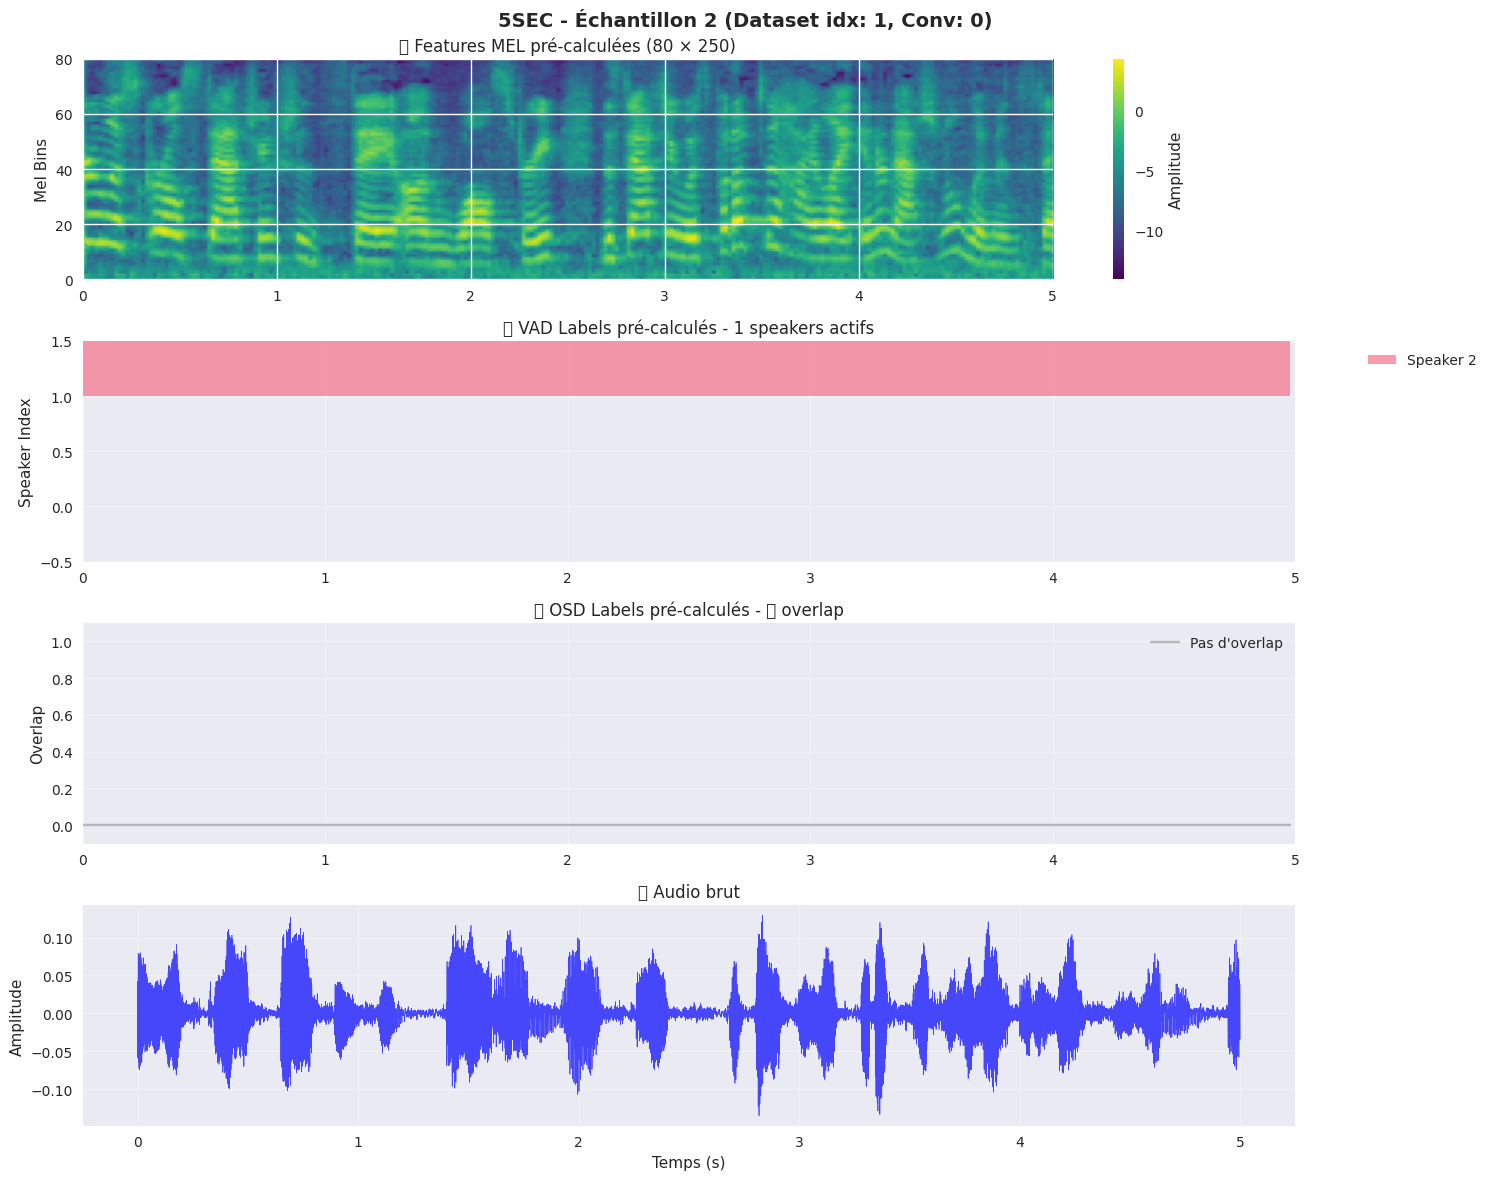

📊 Analyse des données pré-calculées:
   📁 Dataset index: 1 | Conversation: 0 | Start: 2.0s
   🎵 Audio brut: (80000,) samples (5.0s)
   🎼 Features MEL: (80, 250) (mel_bins × frames)
   🎤 VAD labels: (250, 8) (frames × max_speakers)
   🔄 OSD labels: (250,) frames
   📊 Valeurs MEL: [-14.07, 4.32]
   ️ Speakers actifs: 1 ([1])
   🔄 Frames avec overlap: 0/250 (0.0%)
   🤐 Frames avec activité vocale: 250/250 (100.0%)



⏱️ Temps traitement échantillon: 0.38s

⏱️ Échelle 5sec terminée en 0.69s

🎯 Échelle 20SEC (20.0s)
--------------------------------------------------

📊 ÉCHANTILLON 1/2 - 20SEC


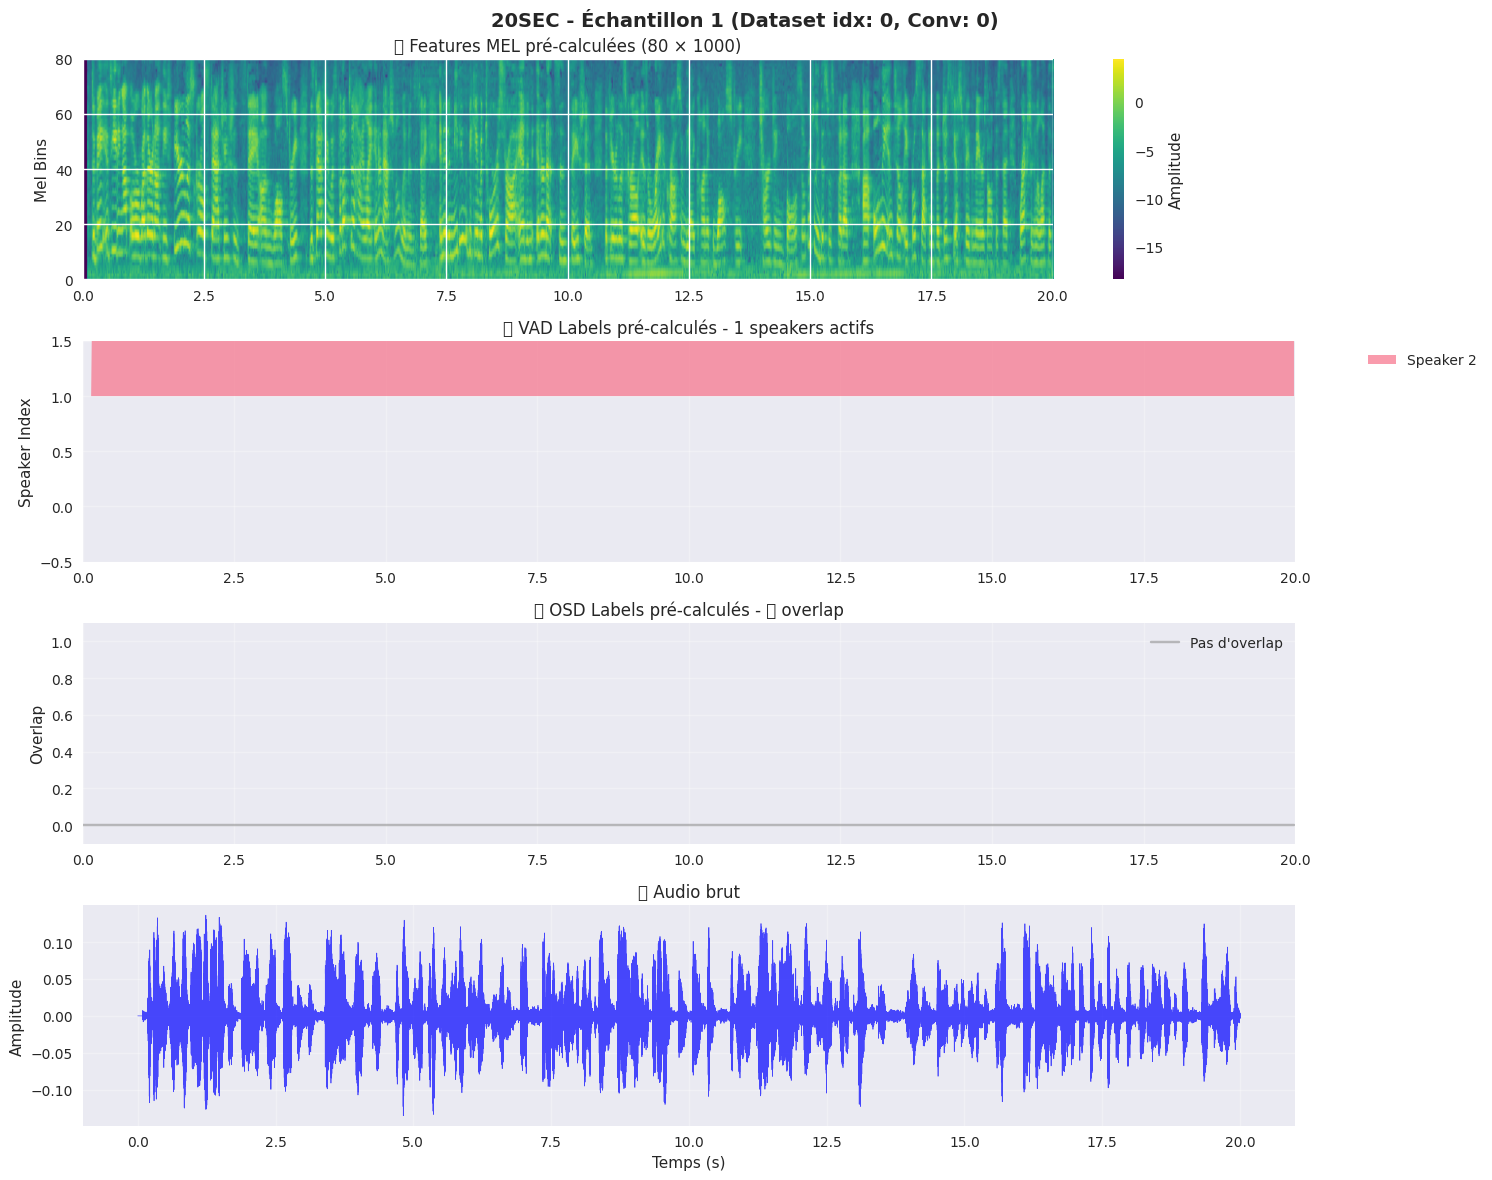

📊 Analyse des données pré-calculées:
   📁 Dataset index: 0 | Conversation: 0 | Start: 0.0s
   🎵 Audio brut: (320000,) samples (20.0s)
   🎼 Features MEL: (80, 1000) (mel_bins × frames)
   🎤 VAD labels: (1000, 8) (frames × max_speakers)
   🔄 OSD labels: (1000,) frames
   📊 Valeurs MEL: [-18.42, 4.46]
   ️ Speakers actifs: 1 ([1])
   🔄 Frames avec overlap: 0/1000 (0.0%)
   🤐 Frames avec activité vocale: 992/1000 (99.2%)



⏱️ Temps traitement échantillon: 0.36s

📊 ÉCHANTILLON 2/2 - 20SEC


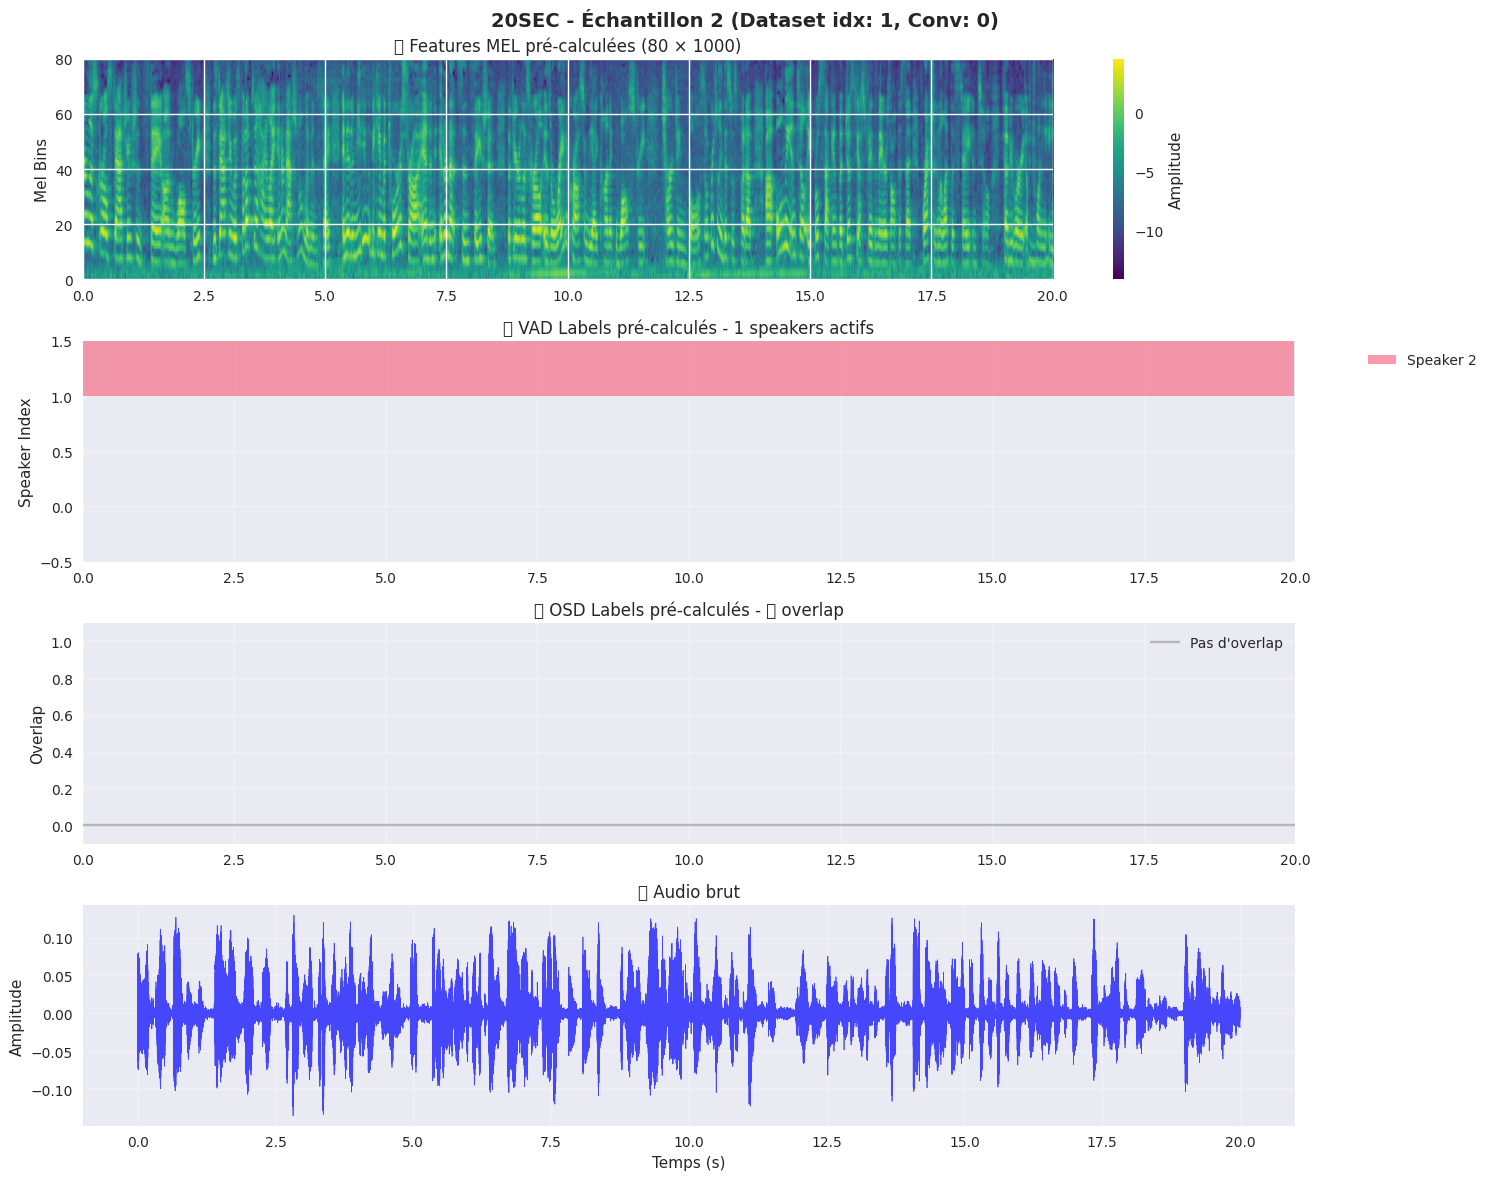

📊 Analyse des données pré-calculées:
   📁 Dataset index: 1 | Conversation: 0 | Start: 2.0s
   🎵 Audio brut: (320000,) samples (20.0s)
   🎼 Features MEL: (80, 1000) (mel_bins × frames)
   🎤 VAD labels: (1000, 8) (frames × max_speakers)
   🔄 OSD labels: (1000,) frames
   📊 Valeurs MEL: [-14.08, 4.47]
   ️ Speakers actifs: 1 ([1])
   🔄 Frames avec overlap: 0/1000 (0.0%)
   🤐 Frames avec activité vocale: 1000/1000 (100.0%)



⏱️ Temps traitement échantillon: 0.35s

⏱️ Échelle 20sec terminée en 0.72s

🎯 Échelle 1MIN (60.0s)
--------------------------------------------------

📊 ÉCHANTILLON 1/2 - 1MIN


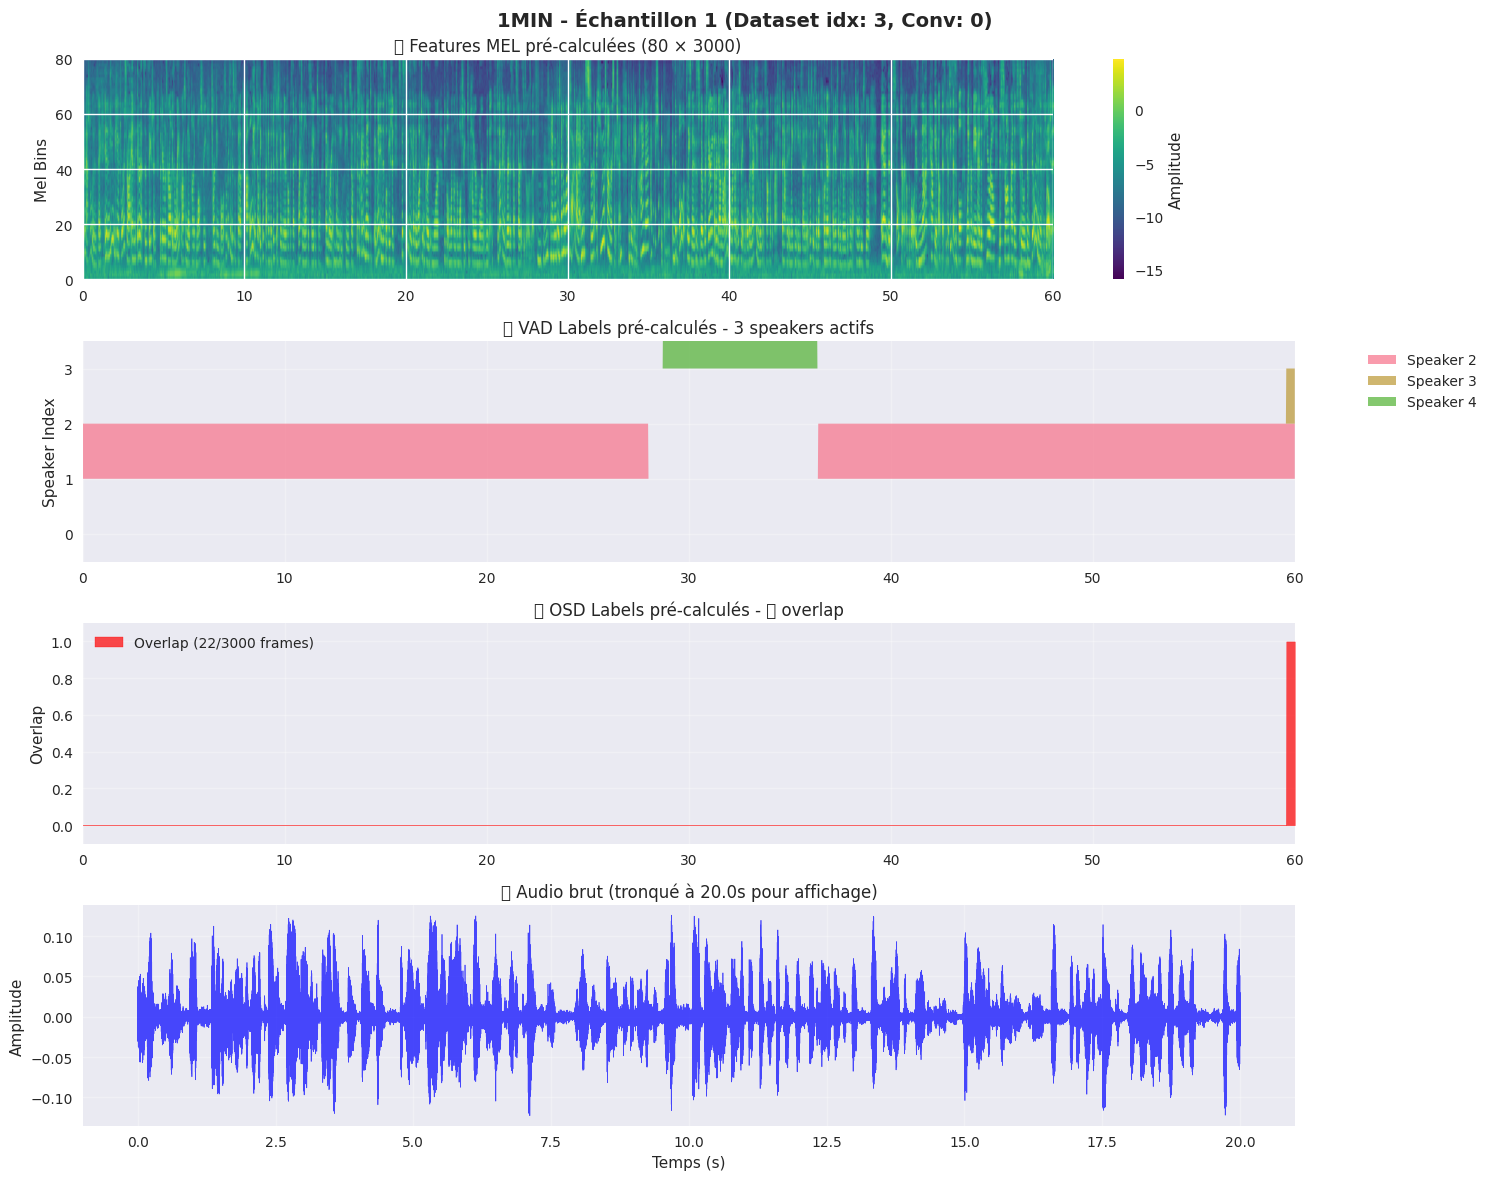

📊 Analyse des données pré-calculées:
   📁 Dataset index: 3 | Conversation: 0 | Start: 6.0s
   🎵 Audio brut: (960000,) samples (60.0s)
   🎼 Features MEL: (80, 3000) (mel_bins × frames)
   🎤 VAD labels: (3000, 8) (frames × max_speakers)
   🔄 OSD labels: (3000,) frames
   📊 Valeurs MEL: [-15.93, 4.80]
   ️ Speakers actifs: 3 ([1, 2, 3])
   🔄 Frames avec overlap: 22/3000 (0.7%)
   🤐 Frames avec activité vocale: 2962/3000 (98.7%)



⏱️ Temps traitement échantillon: 0.38s

📊 ÉCHANTILLON 2/2 - 1MIN


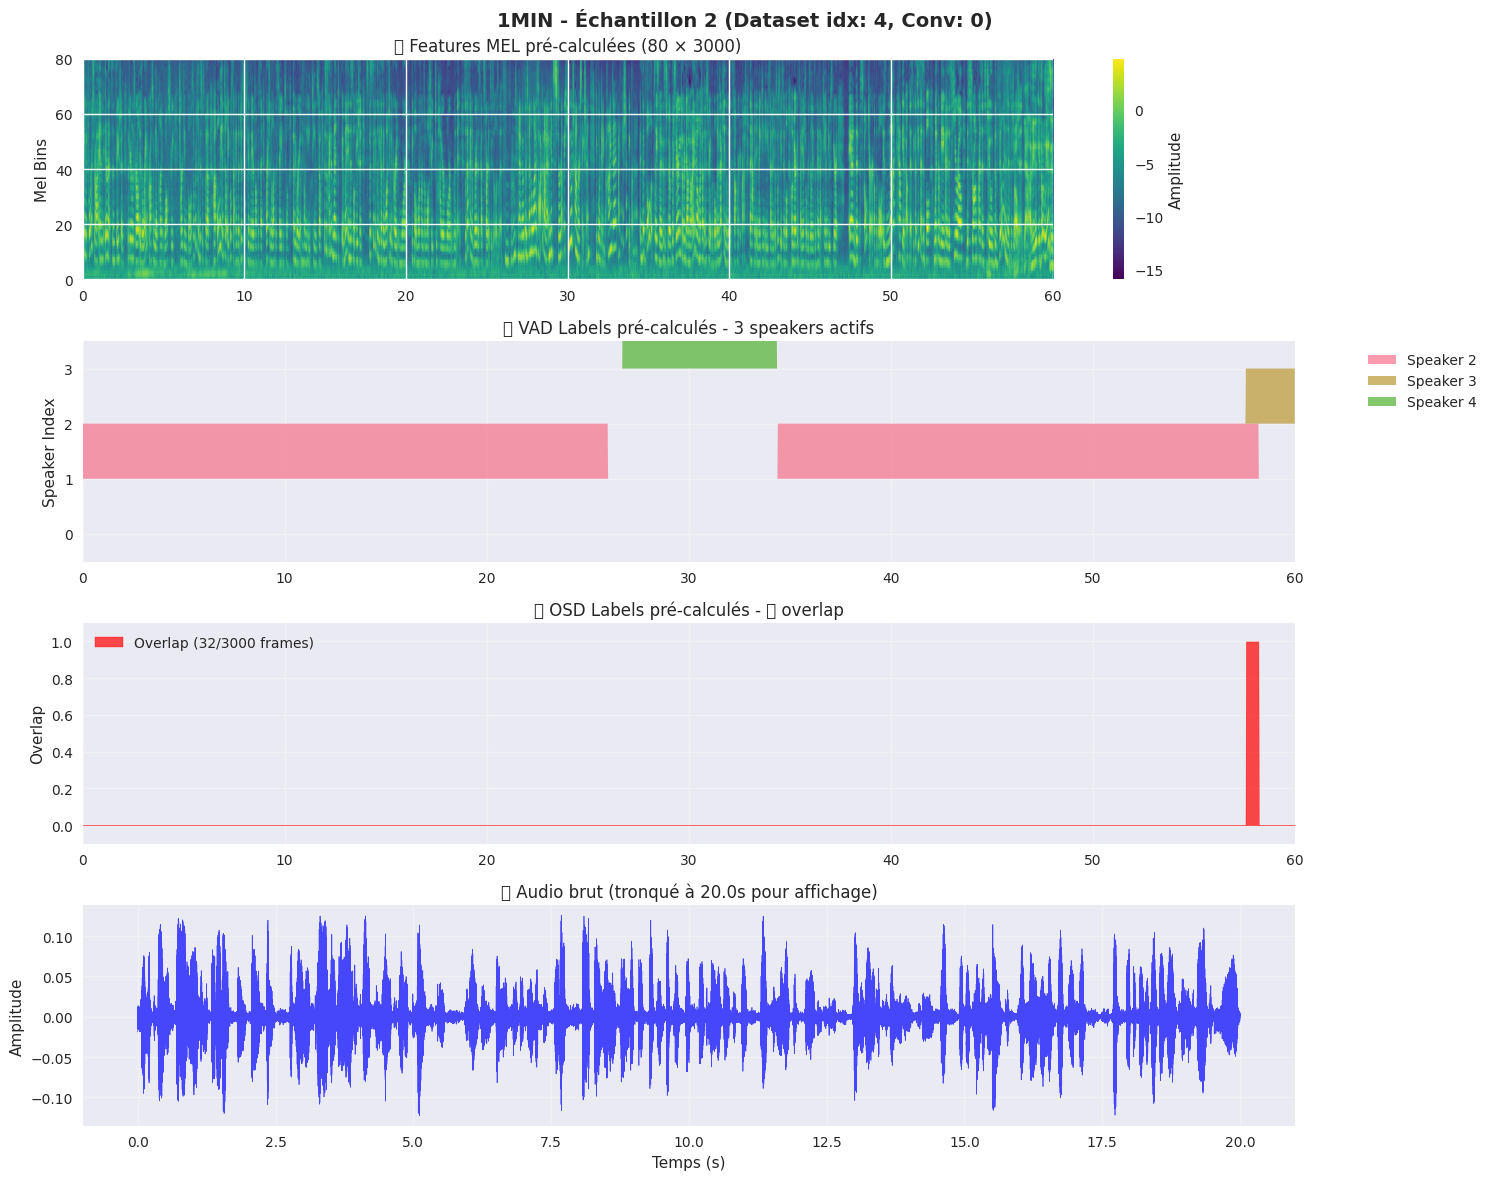

📊 Analyse des données pré-calculées:
   📁 Dataset index: 4 | Conversation: 0 | Start: 8.0s
   🎵 Audio brut: (960000,) samples (60.0s)
   🎼 Features MEL: (80, 3000) (mel_bins × frames)
   🎤 VAD labels: (3000, 8) (frames × max_speakers)
   🔄 OSD labels: (3000,) frames
   📊 Valeurs MEL: [-15.92, 4.80]
   ️ Speakers actifs: 3 ([1, 2, 3])
   🔄 Frames avec overlap: 32/3000 (1.1%)
   🤐 Frames avec activité vocale: 2962/3000 (98.7%)



⏱️ Temps traitement échantillon: 0.39s

⏱️ Échelle 1min terminée en 0.77s

✅ ANALYSE TERMINÉE: 6 échantillons en 2.17s


In [ ]:
import time

def get_dataset_samples_for_analysis(num_samples_per_scale=4):
    """Récupère des échantillons directement depuis VoxConverseDataset pour chaque échelle."""
    print("📊 Récupération d'échantillons depuis VoxConverseDataset...")
    
    # Import du dataset
    sys.path.append('/home/dev/Speaker-diarization-/src')
    from voxconverse_dataset import VoxConverseDataset
    
    samples_by_scale = {}
    
    for scale_name, duration in TIME_SCALES.items():
        print(f"\n🔍 Collecte pour échelle {scale_name} ({duration}s)...")
        
        # Chargement du dataset avec la durée correspondante
        dataset = VoxConverseDataset(split='dev', segment_duration=duration)
        
        print(f"   📊 Dataset chargé: {len(dataset)} segments disponibles")
        
        # Sélection de quelques échantillons intéressants
        selected_samples = []
        
        # Recherche d'échantillons avec overlaps et activité vocale
        for i in range(len(dataset)):  
            sample = dataset[i]
            print(f"   Analyse échantillon {i+1}/{len(dataset)}: Conv {sample['conv_idx']}, Start {sample['start_time']:.1f}s")
            
            # Vérifier s'il y a de l'activité vocale
            vad_activity = sample['vad_labels'].sum().item()
            osd_activity = sample['osd_labels'].sum().item()
            
            if vad_activity > 0:  # Au moins de l'activité vocale
                # Calculer quelques métriques
                num_active_speakers = (sample['vad_labels'].sum(dim=0) > 0).sum().item()
                has_overlap = osd_activity > 0
                
                # Score de priorité (favorise les échantillons avec overlaps et multiple speakers)
                score = num_active_speakers + (2 if has_overlap else 0)
                
                selected_samples.append({
                    'dataset_idx': i,
                    'sample': sample,
                    'score': score,
                    'num_speakers': num_active_speakers,
                    'has_overlap': has_overlap
                })
                
                if len(selected_samples) >= num_samples_per_scale * 3:  # Plus que nécessaire pour sélection
                    break
        
        # Tri par score et sélection des meilleurs
        selected_samples.sort(key=lambda x: x['score'], reverse=True)
        final_samples = selected_samples[:num_samples_per_scale]
        
        samples_by_scale[scale_name] = final_samples
        print(f"   ✅ {len(final_samples)} échantillons sélectionnés")
        
        # Résumé des échantillons sélectionnés
        for j, item in enumerate(final_samples, 1):
            print(f"     #{j}: Dataset idx {item['dataset_idx']}, {item['num_speakers']} speakers, overlap: {'✅' if item['has_overlap'] else '❌'}")
    
    return samples_by_scale

def plot_dataset_sample_analysis(sample_data, scale_name, sample_idx):
    """Affiche l'analyse d'un échantillon en utilisant les données pré-calculées du dataset."""
    sample = sample_data['sample']
    dataset_idx = sample_data['dataset_idx']
    
    # Extraction des données pré-calculées
    features = sample['features'].numpy()  # MEL spectrogram : (80, 200)
    vad_labels = sample['vad_labels'].numpy()  # VAD : (200, 8)
    osd_labels = sample['osd_labels'].numpy()  # OSD : (200,)
    audio = sample['audio'].numpy()  # Audio : (64000,)
    
    # Calcul de l'axe temporel
    num_frames = vad_labels.shape[0]  # 200 frames
    time_frames = np.arange(num_frames) * FRAME_DURATION  # 200 × 0.02s = 4s
    
    # Axe temporel pour l'audio
    sample_rate = 16000  # Sample rate standard
    audio_duration = len(audio) / sample_rate
    time_audio = np.linspace(0, audio_duration, len(audio))
    
    # Axe temporel pour les features MEL (aligné sur les frames)
    mel_time = np.linspace(0, num_frames * FRAME_DURATION, features.shape[1])
    
    # Configuration de la figure
    fig, axes = plt.subplots(4, 1, figsize=(15, 12))
    fig.suptitle(f'{scale_name.upper()} - Échantillon {sample_idx} (Dataset idx: {dataset_idx}, Conv: {sample["conv_idx"]})', 
                 fontsize=14, fontweight='bold')
    
    # 1. Features MEL pré-calculées
    ax1 = axes[0]
    mel_display = ax1.imshow(features, aspect='auto', origin='lower', 
                            extent=[0, num_frames * FRAME_DURATION, 0, features.shape[0]],
                            cmap='viridis')
    ax1.set_ylabel('Mel Bins')
    ax1.set_title(f'🎵 Features MEL pré-calculées ({features.shape[0]} × {features.shape[1]})')
    plt.colorbar(mel_display, ax=ax1, label='Amplitude')
    
    # 2. VAD labels pré-calculés
    ax2 = axes[1]
    # Identifier les speakers actifs
    active_speaker_indices = []
    for speaker_idx in range(vad_labels.shape[1]):
        if vad_labels[:, speaker_idx].sum() > 0:
            active_speaker_indices.append(speaker_idx)
    
    # Affichage des VAD labels pour chaque speaker actif
    for i, speaker_idx in enumerate(active_speaker_indices):
        speaker_activity = vad_labels[:, speaker_idx]
        ax2.fill_between(time_frames, speaker_idx, speaker_idx + speaker_activity, 
                        alpha=0.7, label=f'Speaker {speaker_idx+1}')
    
    ax2.set_ylabel('Speaker Index')
    ax2.set_title(f'🎤 VAD Labels pré-calculés - {len(active_speaker_indices)} speakers actifs')
    ax2.set_xlim(0, num_frames * FRAME_DURATION)
    ax2.set_ylim(-0.5, min(8, len(active_speaker_indices)) + 0.5)
    if active_speaker_indices:
        ax2.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    ax2.grid(True, alpha=0.3)
    
    # 3. OSD labels pré-calculés
    ax3 = axes[2]
    overlap_frames = np.sum(osd_labels > 0)
    if overlap_frames > 0:
        ax3.fill_between(time_frames, 0, osd_labels, alpha=0.7, color='red', 
                        label=f'Overlap ({overlap_frames}/{len(osd_labels)} frames)')
    else:
        ax3.plot(time_frames, osd_labels, color='gray', alpha=0.5, label='Pas d\'overlap')
    
    ax3.set_ylabel('Overlap')
    ax3.set_title(f'🔄 OSD Labels pré-calculés - {"✅" if overlap_frames > 0 else "❌"} overlap')
    ax3.set_xlim(0, num_frames * FRAME_DURATION)
    ax3.set_ylim(-0.1, 1.1)
    ax3.legend()
    ax3.grid(True, alpha=0.3)
    
    # 4. Audio brut (tronqué pour l'affichage si nécessaire)
    ax4 = axes[3]
    # Limiter l'affichage pour la lisibilité
    max_display_samples = 320000  # ~20s à 16kHz
    if len(audio) > max_display_samples:
        display_audio = audio[:max_display_samples]
        display_time = time_audio[:max_display_samples]
        title_suffix = f" (tronqué à {max_display_samples/sample_rate:.1f}s pour affichage)"
    else:
        display_audio = audio
        display_time = time_audio
        title_suffix = ""
    
    ax4.plot(display_time, display_audio, color='blue', alpha=0.7, linewidth=0.5)
    ax4.set_xlabel('Temps (s)')
    ax4.set_ylabel('Amplitude')
    ax4.set_title(f'🔊 Audio brut{title_suffix}')
    ax4.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Statistiques détaillées des données pré-calculées
    print(f"📊 Analyse des données pré-calculées:")
    print(f"   📁 Dataset index: {dataset_idx} | Conversation: {sample['conv_idx']} | Start: {sample['start_time']:.1f}s")
    print(f"   🎵 Audio brut: {audio.shape} samples ({audio_duration:.1f}s)")
    print(f"   🎼 Features MEL: {features.shape} (mel_bins × frames)")
    print(f"   🎤 VAD labels: {vad_labels.shape} (frames × max_speakers)")
    print(f"   🔄 OSD labels: {osd_labels.shape} frames")
    print(f"   📊 Valeurs MEL: [{features.min():.2f}, {features.max():.2f}]")
    print(f"   ️ Speakers actifs: {len(active_speaker_indices)} ({active_speaker_indices})")
    print(f"   🔄 Frames avec overlap: {overlap_frames}/{len(osd_labels)} ({overlap_frames/len(osd_labels)*100:.1f}%)")
    print(f"   🤐 Frames avec activité vocale: {np.sum(vad_labels.sum(axis=1) > 0)}/{len(vad_labels)} ({np.sum(vad_labels.sum(axis=1) > 0)/len(vad_labels)*100:.1f}%)")

def display_dataset_samples_analysis(samples_dict):
    """Affiche l'analyse complète des échantillons du dataset."""
    print("🎵 ANALYSE DES DONNÉES PRÉ-CALCULÉES DU DATASET")
    print("=" * 70)
    
    total_start = time.time()
    total_samples = 0
    
    for scale_name, samples in samples_dict.items():
        duration = TIME_SCALES[scale_name]
        
        print(f"\n🎯 Échelle {scale_name.upper()} ({duration}s)")
        print("-" * 50)
        
        if not samples:
            print("❌ Aucun échantillon disponible")
            continue
            
        scale_start = time.time()
        
        for i, sample_data in enumerate(samples, 1):
            sample_start = time.time()
            
            print(f"\n{'='*60}")
            print(f"📊 ÉCHANTILLON {i}/{len(samples)} - {scale_name.upper()}")
            print(f"{'='*60}")
            
            # Affichage de l'analyse des données pré-calculées
            plot_dataset_sample_analysis(sample_data, scale_name, i)
            
            # Widget audio pour écoute
            audio_tensor = sample_data['sample']['audio']
            audio_numpy = audio_tensor.numpy()
            
            title = f"{scale_name.upper()} - Échantillon {i} (Dataset idx {sample_data['dataset_idx']})"
            audio_widget = create_audio_widget_optimized(
                audio_numpy, 
                16000,  # Sample rate
                title
            )
            
            display(audio_widget)
            
            sample_time = time.time() - sample_start
            print(f"\n⏱️ Temps traitement échantillon: {sample_time:.2f}s")
            total_samples += 1
        
        scale_time = time.time() - scale_start
        print(f"\n⏱️ Échelle {scale_name} terminée en {scale_time:.2f}s")
    
    total_time = time.time() - total_start
    print(f"\n✅ ANALYSE TERMINÉE: {total_samples} échantillons en {total_time:.2f}s")

def create_audio_widget_optimized(audio_segment, sample_rate, title="Audio"):
    """Version optimisée du widget audio avec gestion de la taille et performance."""
    if len(audio_segment) == 0:
        return HTML(f"<div><strong>{title}</strong>: Segment audio vide</div>")
    
    # Limite drastique pour éviter les problèmes de performance
    max_duration = 60  # Réduit à 60 secondes max
    if len(audio_segment) / sample_rate > max_duration:
        max_samples = int(max_duration * sample_rate)
        audio_segment = audio_segment[:max_samples]
        title += f" (tronqué à {max_duration}s)"
    
    # Downsample agressif pour réduire la taille
    target_sample_rate = 8000  # Réduit à 8kHz pour économiser l'espace
    if sample_rate > target_sample_rate:
        downsample_factor = sample_rate // target_sample_rate
        audio_segment = audio_segment[::downsample_factor]
        sample_rate = target_sample_rate
        title += f" (8kHz)"
    
    # Conversion en tensor PyTorch
    audio_tensor = torch.from_numpy(audio_segment).float()
    if audio_tensor.dim() == 1:
        audio_tensor = audio_tensor.unsqueeze(0)
    
    # Conversion en base64 optimisée
    buffer = io.BytesIO()
    torchaudio.save(buffer, audio_tensor, sample_rate, format="wav")
    buffer.seek(0)
    audio_b64 = base64.b64encode(buffer.read()).decode('utf-8')
    
    # Widget HTML simplifié
    html = f"""
    <div style="margin: 8px 0; padding: 8px; border: 1px solid #ddd; border-radius: 6px; background-color: #f9f9f9;">
        <h4 style="margin: 0 0 8px 0; color: #333; font-size: 14px;">{title}</h4>
        <audio controls style="width: 100%; height: 35px;">
            <source src="data:audio/wav;base64,{audio_b64}" type="audio/wav">
            Votre navigateur ne supporte pas l'élément audio.
        </audio>
        <div style="font-size: 11px; color: #666; margin-top: 4px;">
            {len(audio_segment)/sample_rate:.1f}s | {sample_rate}Hz | {len(audio_b64)//1024}KB
        </div>
    </div>
    """
    return HTML(html)

# Récupération et affichage des échantillons du dataset
print("🎵 ANALYSE DES DONNÉES PRÉ-CALCULÉES DU VOXCONVERSE DATASET")
print("=" * 70)

# Récupération d'échantillons directement depuis VoxConverseDataset
dataset_samples = get_dataset_samples_for_analysis(SAMPLES_PER_SCALE)

if dataset_samples:
    # Vérification du nombre total d'échantillons
    total_count = sum(len(samples) for samples in dataset_samples.values())
    print(f"📊 Total échantillons à analyser: {total_count}")
    
    if total_count > 0:
        display_dataset_samples_analysis(dataset_samples)
    else:
        print("❌ Aucun échantillon disponible")
else:
    print("❌ Échec de récupération des échantillons")
    print("🔧 Vérifiez que VoxConverseDataset est correctement configuré")

## 6. 📊 Analyse statistique complète du dataset

In [5]:
def analyze_dataset_statistics(conversations, time_scales, num_conversations=100):
    """Analyse statistique complète du dataset par échelle de temps."""
    print(f"📊 Analyse statistique sur {num_conversations} conversations...")
    
    statistics = {}
    
    for scale_name, segment_duration in time_scales.items():
        print(f"\n🔍 Analyse échelle {scale_name} ({segment_duration}s)...")
        
        # Collecte des statistiques
        speaker_counts = []
        silence_ratios = []
        overlap_ratios = []
        max_concurrent_speakers = []
        total_segments = 0
        
        for conv_idx, conversation in enumerate(conversations[:num_conversations]):
            if conv_idx % 20 == 0:
                print(f"  Progression: {conv_idx+1}/{num_conversations}")
                
            try:
                # Utilisation de la fonction sécurisée
                conv_data = safe_get_conversation_data(conversation, conv_idx)
                
                audio_array = conv_data['audio_array']
                sample_rate = conv_data['sample_rate']
                conv_duration = conv_data['duration']
                timestamps_start = conv_data['timestamps_start']
                timestamps_end = conv_data['timestamps_end']
                speakers = conv_data['speakers']
                
                # Skip si trop court
                if conv_duration < segment_duration:
                    continue
                
                # Segmentation avec hop de 50%
                hop_duration = segment_duration * 0.5
                start_time = 0.0
                
                while start_time + segment_duration <= conv_duration:
                    end_time = start_time + segment_duration
                    
                    # Analyse du segment
                    labels_info = create_segment_labels(
                        start_time, end_time,
                        timestamps_start, timestamps_end, speakers
                    )
                    
                    # Collecte des métriques
                    if labels_info['has_speech']:  # Seulement segments avec speech
                        speaker_counts.append(labels_info['num_active_speakers'])
                        silence_ratios.append(labels_info['silence_ratio'])
                        overlap_ratios.append(1.0 if labels_info['has_overlap'] else 0.0)
                        max_concurrent_speakers.append(labels_info['max_concurrent_speakers'])
                        total_segments += 1
                    
                    start_time += hop_duration
                    
            except Exception as e:
                print(f"⚠️ Erreur conversation {conv_idx}: {e}")
                continue
        
        # Calcul des statistiques finales
        if speaker_counts:
            stats = {
                'total_segments': total_segments,
                'speaker_distribution': {
                    'mean': np.mean(speaker_counts),
                    'std': np.std(speaker_counts),
                    'min': np.min(speaker_counts),
                    'max': np.max(speaker_counts),
                    'histogram': np.bincount(speaker_counts)
                },
                'silence_stats': {
                    'mean_ratio': np.mean(silence_ratios),
                    'std_ratio': np.std(silence_ratios),
                    'segments_with_high_silence': np.mean(np.array(silence_ratios) > 0.5)
                },
                'overlap_stats': {
                    'overlap_percentage': np.mean(overlap_ratios) * 100,
                    'max_concurrent_mean': np.mean(max_concurrent_speakers),
                    'max_concurrent_max': np.max(max_concurrent_speakers)
                }
            }
        else:
            stats = {
                'total_segments': 0,
                'error': 'Aucun segment avec speech trouvé'
            }
        
        statistics[scale_name] = stats
        
        # Affichage résumé
        if 'error' not in stats:
            print(f"  ✅ {stats['total_segments']} segments analysés")
            print(f"  🎤 Speakers moyen: {stats['speaker_distribution']['mean']:.1f} ± {stats['speaker_distribution']['std']:.1f}")
            print(f"  🔇 Silence moyen: {stats['silence_stats']['mean_ratio']:.1%}")
            print(f"  🔄 Overlap: {stats['overlap_stats']['overlap_percentage']:.1f}%")
        else:
            print(f"  ❌ {stats['error']}")
    
    return statistics

# Lancement de l'analyse
if voxconverse_dev:
    dataset_stats = analyze_dataset_statistics(voxconverse_dev, TIME_SCALES, num_conversations=50)
    print("\n✅ Analyse statistique terminée!")
else:
    print("❌ Dataset non disponible pour l'analyse")
    dataset_stats = {}

📊 Analyse statistique sur 50 conversations...

🔍 Analyse échelle 5sec (5.0s)...
  Progression: 1/50
⚠️ Erreur conversation 0: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 1: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 2: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 3: name 'safe_get_conversation_data' is not defined
  ❌ Aucun segment avec speech trouvé

🔍 Analyse échelle 20sec (20.0s)...
  Progression: 1/50
⚠️ Erreur conversation 0: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 1: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 2: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 3: name 'safe_get_conversation_data' is not defined
  ❌ Aucun segment avec speech trouvé

🔍 Analyse échelle 20sec (20.0s)...
  Progression: 1/50
⚠️ Erreur conversation 0: name 'safe_get_conversation_data' is not defined
⚠️ Erreur conversation 1: name 'safe_ge

## 7. 📈 Visualisation des distributions et statistiques

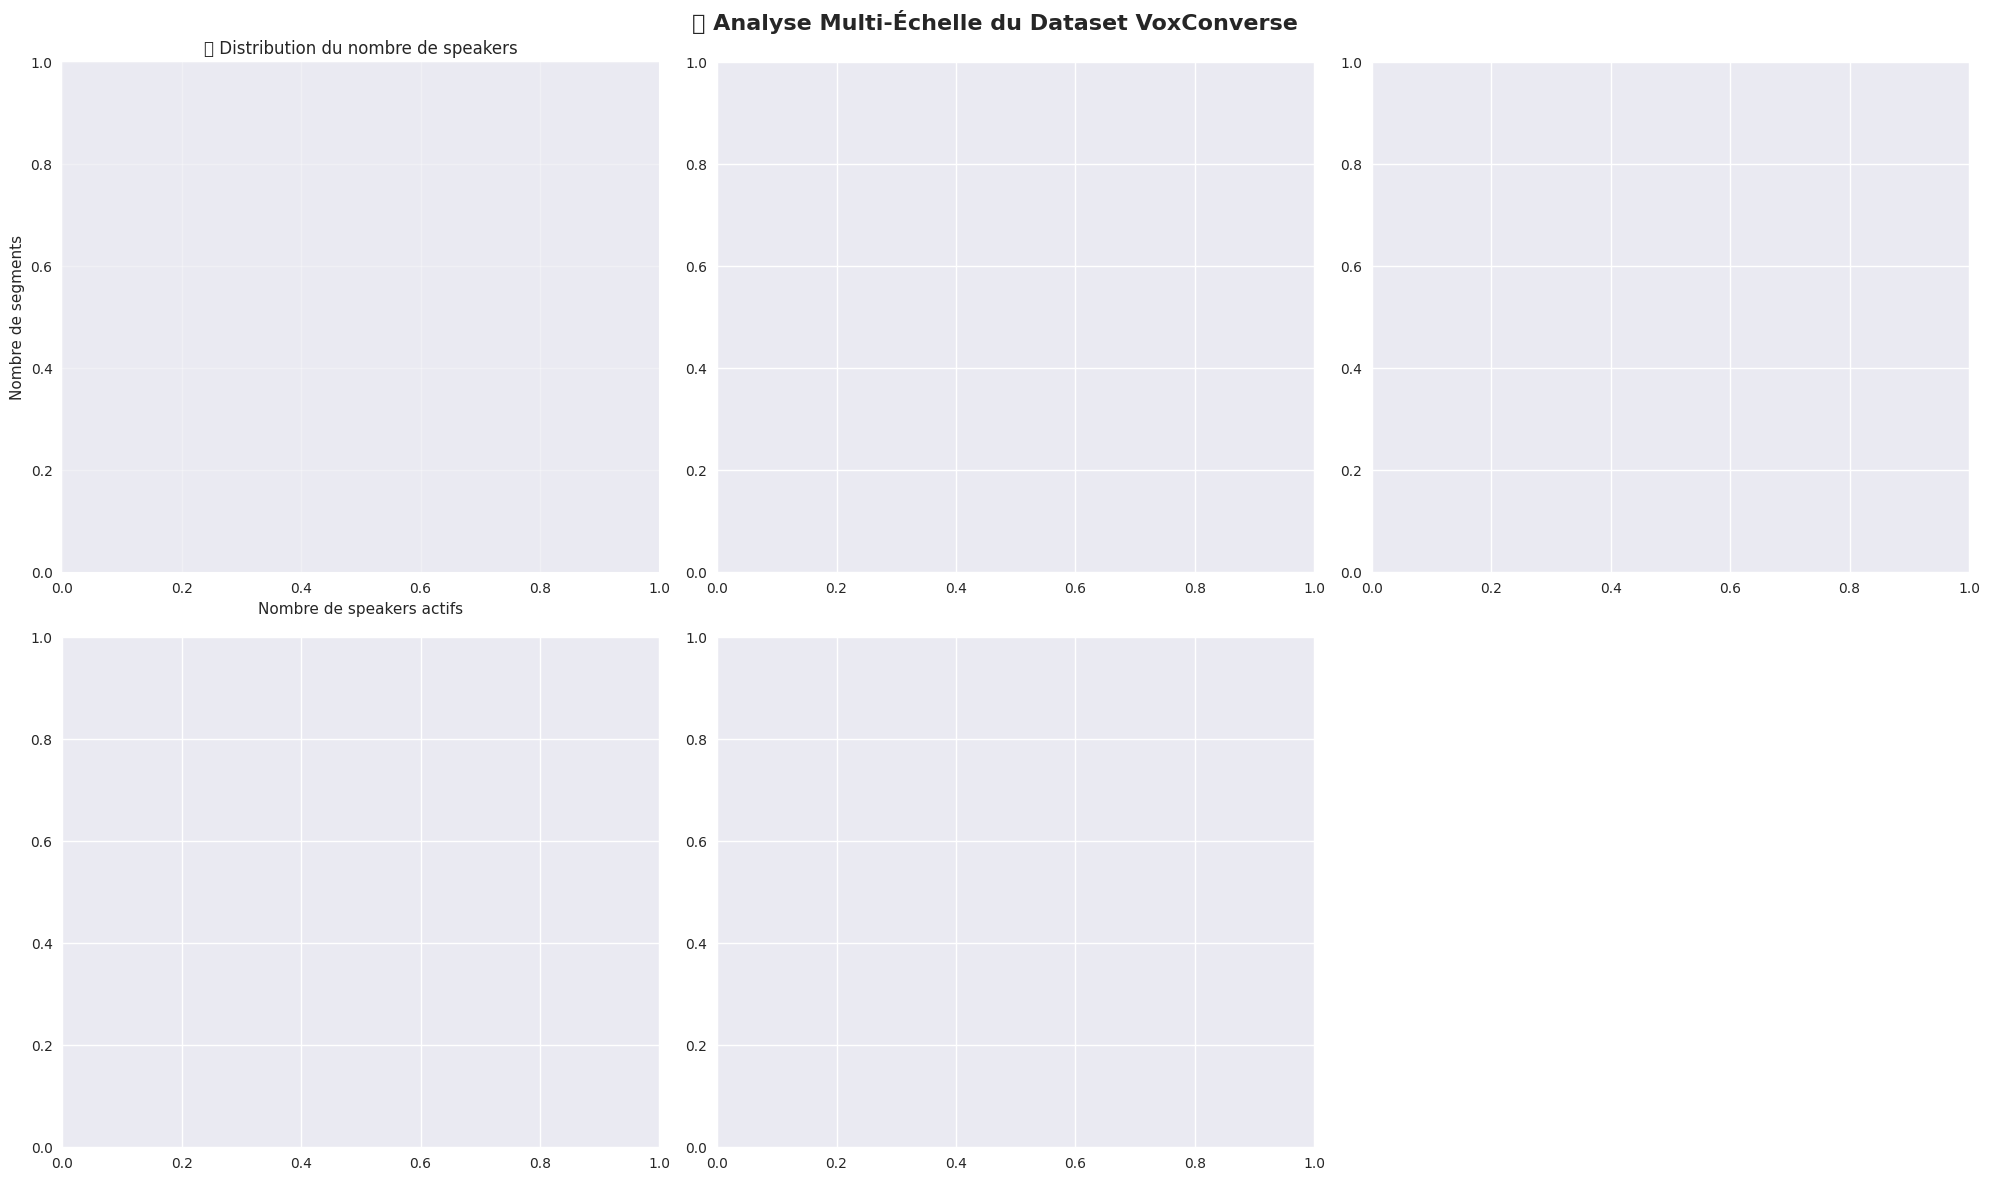


📋 RÉSUMÉ EXÉCUTIF


In [6]:
def plot_dataset_analysis(statistics):
    """Visualise les statistiques du dataset."""
    if not statistics:
        print("❌ Pas de statistiques à visualiser")
        return
    
    # Configuration des graphiques
    fig, axes = plt.subplots(2, 3, figsize=(20, 12))
    fig.suptitle('📊 Analyse Multi-Échelle du Dataset VoxConverse', fontsize=16, fontweight='bold')
    
    scales = list(statistics.keys())
    colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
    
    # 1. Distribution du nombre de speakers
    ax1 = axes[0, 0]
    for i, scale in enumerate(scales):
        if 'error' not in statistics[scale]:
            hist = statistics[scale]['speaker_distribution']['histogram']
            speaker_nums = np.arange(len(hist))
            ax1.bar(speaker_nums + i*0.25, hist, width=0.25, 
                   label=f'{scale} ({TIME_SCALES[scale]}s)', 
                   color=colors[i], alpha=0.7)
    
    ax1.set_xlabel('Nombre de speakers actifs')
    ax1.set_ylabel('Nombre de segments')
    ax1.set_title('🎤 Distribution du nombre de speakers')
    ax1.legend()
    ax1.grid(True, alpha=0.3)
    
    # 2. Pourcentage de silence par échelle
    ax2 = axes[0, 1]
    silence_means = []
    silence_stds = []
    scale_labels = []
    
    for scale in scales:
        if 'error' not in statistics[scale]:
            silence_means.append(statistics[scale]['silence_stats']['mean_ratio'] * 100)
            silence_stds.append(statistics[scale]['silence_stats']['std_ratio'] * 100)
            scale_labels.append(f"{scale}\n({TIME_SCALES[scale]}s)")
    
    if silence_means:
        bars = ax2.bar(scale_labels, silence_means, yerr=silence_stds, 
                      capsize=5, color=colors[:len(silence_means)], alpha=0.7)
        ax2.set_ylabel('Pourcentage de silence (%)')
        ax2.set_title('🔇 Silence par échelle temporelle')
        ax2.grid(True, alpha=0.3)
        
        # Ajout des valeurs sur les barres
        for bar, mean in zip(bars, silence_means):
            ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                    f'{mean:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 3. Pourcentage d'overlap par échelle
    ax3 = axes[0, 2]
    overlap_percentages = []
    
    for scale in scales:
        if 'error' not in statistics[scale]:
            overlap_percentages.append(statistics[scale]['overlap_stats']['overlap_percentage'])
    
    if overlap_percentages:
        bars = ax3.bar(scale_labels, overlap_percentages, 
                      color=colors[:len(overlap_percentages)], alpha=0.7)
        ax3.set_ylabel('Pourcentage d\'overlap (%)')
        ax3.set_title('🔄 Overlaps par échelle temporelle')
        ax3.grid(True, alpha=0.3)
        
        # Ajout des valeurs sur les barres
        for bar, pct in zip(bars, overlap_percentages):
            ax3.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                    f'{pct:.1f}%', ha='center', va='bottom', fontweight='bold')
    
    # 4. Nombre moyen de speakers par échelle
    ax4 = axes[1, 0]
    speaker_means = []
    speaker_stds = []
    
    for scale in scales:
        if 'error' not in statistics[scale]:
            speaker_means.append(statistics[scale]['speaker_distribution']['mean'])
            speaker_stds.append(statistics[scale]['speaker_distribution']['std'])
    
    if speaker_means:
        bars = ax4.bar(scale_labels, speaker_means, yerr=speaker_stds,
                      capsize=5, color=colors[:len(speaker_means)], alpha=0.7)
        ax4.set_ylabel('Nombre moyen de speakers')
        ax4.set_title('🎤 Speakers moyens par échelle')
        ax4.grid(True, alpha=0.3)
        
        # Ajout des valeurs sur les barres
        for bar, mean in zip(bars, speaker_means):
            ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
                    f'{mean:.2f}', ha='center', va='bottom', fontweight='bold')
    
    # 5. Nombre total de segments par échelle
    ax5 = axes[1, 1]
    total_segments = []
    
    for scale in scales:
        if 'error' not in statistics[scale]:
            total_segments.append(statistics[scale]['total_segments'])
    
    if total_segments:
        bars = ax5.bar(scale_labels, total_segments, 
                      color=colors[:len(total_segments)], alpha=0.7)
        ax5.set_ylabel('Nombre de segments')
        ax5.set_title('📊 Total segments analysés')
        ax5.grid(True, alpha=0.3)
        
        # Ajout des valeurs sur les barres
        for bar, total in zip(bars, total_segments):
            ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + max(total_segments)*0.01,
                    f'{total:,}', ha='center', va='bottom', fontweight='bold')
    
    # 6. Tableau de synthèse
    ax6 = axes[1, 2]
    ax6.axis('off')
    
    # Création du tableau de synthèse
    table_data = []
    headers = ['Échelle', 'Durée', 'Segments', 'Speakers', 'Silence', 'Overlap']
    
    for scale in scales:
        if 'error' not in statistics[scale]:
            stats = statistics[scale]
            row = [
                scale.upper(),
                f"{TIME_SCALES[scale]}s",
                f"{stats['total_segments']:,}",
                f"{stats['speaker_distribution']['mean']:.1f}",
                f"{stats['silence_stats']['mean_ratio']:.1%}",
                f"{stats['overlap_stats']['overlap_percentage']:.1f}%"
            ]
            table_data.append(row)
    
    if table_data:
        table = ax6.table(cellText=table_data, colLabels=headers,
                         cellLoc='center', loc='center')
        table.auto_set_font_size(False)
        table.set_fontsize(10)
        table.scale(1, 2)
        
        # Style du tableau
        for i in range(len(headers)):
            table[(0, i)].set_facecolor('#4ECDC4')
            table[(0, i)].set_text_props(weight='bold', color='white')
        
        ax6.set_title('📋 Résumé des statistiques', fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.show()
    
    # Affichage du résumé textuel
    print("\n📋 RÉSUMÉ EXÉCUTIF")
    print("=" * 50)
    
    for scale in scales:
        if 'error' not in statistics[scale]:
            stats = statistics[scale]
            duration = TIME_SCALES[scale]
            
            print(f"\n🎯 {scale.upper()} ({duration}s):")
            print(f"   📊 {stats['total_segments']:,} segments analysés")
            print(f"   🎤 {stats['speaker_distribution']['mean']:.1f} ± {stats['speaker_distribution']['std']:.1f} speakers en moyenne")
            print(f"   🔇 {stats['silence_stats']['mean_ratio']:.1%} de silence en moyenne")
            print(f"   🔄 {stats['overlap_stats']['overlap_percentage']:.1f}% de segments avec overlap")
            print(f"   📈 Max {stats['overlap_stats']['max_concurrent_max']} speakers simultanés")

# Visualisation
if dataset_stats:
    plot_dataset_analysis(dataset_stats)
else:
    print("❌ Pas de statistiques à visualiser")